In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 1
import os

# This line MUST be executed before TensorFlow is imported for the first time.
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Now, this check will correctly show that no GPUs are visible.
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Import Library

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from keras.models import Sequential,Model
from keras.layers import Input,Conv1D,ReLU,BatchNormalization,LSTM,Dropout,GlobalAveragePooling1D,Dense,LeakyReLU,AveragePooling1D,TimeDistributed,RepeatVector,Bidirectional,GRU
from keras.optimizers import Adam
from keras.callbacks import  EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error
from keras import regularizers
import keras_tuner as kt
import keras

# Import Data

In [4]:
x_train = pd.read_csv('x_train_FD2.csv')
x_test = pd.read_csv('x_test_FD2.csv')

x_train_PCA_Weight = pd.read_csv('x_train_pca_weight_FD2.csv')
x_test_PCA_Weight = pd.read_csv('x_test_pca_weight_FD2.csv')

x_train_corr = pd.read_csv('x_train_Corr_FD2.csv')
x_test_corr = pd.read_csv('x_test_Corr_FD2.csv')

X_train_pca = pd.read_csv('x_train_pca_FD2.csv')
X_test_pca = pd.read_csv('x_test_pca_FD2.csv')

y_train = pd.read_csv('y_train_FD2.csv')
y_test = pd.read_csv('y_test_FD2.csv')

In [5]:
x_train

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,314.05,2389.02,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,371.22,2388.42,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,163.74,2030.33,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,164.37,2030.35,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729


In [6]:
x_test

,unit_number,time_cycles,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,9.9987,0.2502,100.0,489.05,605.03,1497.17,1304.99,10.52,...,371.69,2388.18,8114.10,8.6476,0.03,369,2319,100.00,28.42,17.1551
1,1,2,20.0026,0.7000,100.0,491.19,607.82,1481.20,1246.11,9.35,...,315.32,2388.12,8053.06,9.2405,0.02,364,2324,100.00,24.29,14.8039
2,1,3,35.0045,0.8400,100.0,449.44,556.00,1359.08,1128.36,5.48,...,183.04,2387.75,8053.04,9.3472,0.02,333,2223,100.00,14.98,8.9125
3,1,4,42.0066,0.8410,100.0,445.00,550.17,1349.69,1127.89,3.91,...,130.40,2387.72,8066.90,9.3961,0.02,332,2212,100.00,10.35,6.4181
4,1,5,24.9985,0.6213,60.0,462.54,536.72,1253.18,1050.69,7.05,...,164.56,2028.05,7865.66,10.8682,0.02,305,1915,84.93,14.31,8.5740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33986,259,119,35.0015,0.8403,100.0,449.44,555.56,1366.01,1129.47,5.48,...,183.05,2388.39,8088.36,9.3215,0.02,334,2223,100.00,14.94,8.9065
33987,259,120,42.0066,0.8405,100.0,445.00,549.42,1351.13,1123.86,3.91,...,130.74,2388.31,8108.48,9.3542,0.02,332,2212,100.00,10.57,6.4075
33988,259,121,42.0061,0.8400,100.0,445.00,549.65,1349.14,1118.91,3.91,...,130.96,2388.34,8098.77,9.3836,0.02,331,2212,100.00,10.57,6.4805
33989,259,122,0.0024,0.0003,100.0,518.67,642.58,1589.61,1408.16,14.62,...,522.25,2388.00,8161.85,8.4279,0.03,393,2388,100.00,39.08,23.3589


In [7]:
x_train_PCA_Weight

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_17,sensor_18,sensor_20,sensor_21
0,449.44,555.32,1358.61,1137.23,5.48,8.00,194.64,2222.65,8341.91,1.02,42.02,183.06,334,2223,14.73,8.8071
1,445.00,549.90,1353.22,1125.78,3.91,5.71,138.51,2211.57,8303.96,1.02,42.20,130.42,330,2212,10.41,6.2665
2,462.54,537.31,1256.76,1047.45,7.05,9.02,175.71,1915.11,8001.42,0.94,36.69,164.22,309,1915,14.08,8.6723
3,445.00,549.51,1354.03,1126.38,3.91,5.71,138.46,2211.58,8303.96,1.02,41.96,130.72,329,2212,10.59,6.4701
4,462.54,537.07,1257.71,1047.93,7.05,9.03,175.05,1915.10,7993.23,0.94,36.89,164.31,309,1915,14.13,8.5286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,491.19,608.79,1495.60,1269.51,9.35,13.66,334.00,2324.92,8852.27,1.07,44.72,314.05,369,2324,24.36,14.5189
53755,489.05,605.81,1514.32,1324.12,10.52,15.50,392.46,2319.17,8915.86,1.26,46.08,371.22,374,2319,28.10,16.9454
53756,462.54,537.48,1276.24,1057.92,7.05,9.04,175.11,1917.37,8114.33,0.94,37.14,163.74,310,1915,14.19,8.5503
53757,462.54,537.84,1272.95,1066.30,7.05,9.04,174.81,1917.36,8112.63,0.94,37.32,164.37,311,1915,14.05,8.3729


In [8]:
x_train_corr

,sensor_14,sensor_11,sensor_16,sensor_17,sensor_9,sensor_3,sensor_15,sensor_4
0,8048.56,42.02,0.02,334,8341.91,1358.61,9.3461,1137.23
1,8072.30,42.20,0.02,330,8303.96,1353.22,9.3774,1125.78
2,7864.87,36.69,0.02,309,8001.42,1256.76,10.8941,1047.45
3,8068.66,41.96,0.02,329,8303.96,1354.03,9.3528,1126.38
4,7861.23,36.89,0.02,309,7993.23,1257.71,10.8963,1047.93
...,...,...,...,...,...,...,...,...
53754,8169.64,44.72,0.03,369,8852.27,1495.60,9.3035,1269.51
53755,8245.36,46.08,0.03,374,8915.86,1514.32,8.7586,1324.12
53756,7971.25,37.14,0.02,310,8114.33,1276.24,11.0657,1057.92
53757,7972.47,37.32,0.02,311,8112.63,1272.95,11.0537,1066.30


In [9]:
X_train_pca

,PC1,PC2,PC3
0,-2.193283,1.610639,-0.172923
1,-2.960044,2.218475,0.234083
2,-5.997478,-4.311099,-0.009899
3,-2.973606,2.194856,0.229045
4,-5.999720,-4.313578,-0.016556
...,...,...,...
53754,2.444970,0.606522,-0.071182
53755,4.245973,0.189138,1.228054
53756,-5.644978,-3.956132,0.243159
53757,-5.618881,-3.934608,0.248594


In [10]:
y_train

,RUL
0,130
1,130
2,130
3,130
4,130
...,...
53754,4
53755,3
53756,2
53757,1


In [11]:
y_test

,RUL
0,18
1,79
2,106
3,110
4,15
...,...
254,122
255,130
256,56
257,130


In [12]:
print('(Num of Train Samples , Num of Features) : {}'.format(x_train.shape))
print('(Num of Test Samples , Num of Features) : {}\n'.format(x_test.shape))

print('(Num of Train Samples , Num of Features)-PCA_Weight : {}'.format(x_train_PCA_Weight.shape))
print('(Num of Test Samples , Num of Features)-PCA_Weight : {}\n'.format(x_test_PCA_Weight.shape))

print('(Num of Train Samples , Num of Features)-Corr : {}'.format(x_train_corr.shape))
print('(Num of Test Samples , Num of Features)-Corr : {}\n'.format(x_test_corr.shape))

print('(Num of Train Samples , Num of Features)-pca : {}'.format(X_train_pca.shape))
print('(Num of Test Samples , Num of Features)-pca : {}\n'.format(X_test_pca.shape))

print('(Num of Train Targets) : {}'.format(y_train.shape[0]))
print('(Num of Test Targets) : {}\n'.format(y_test.shape[0]))

(Num of Train Samples , Num of Features) : (53759, 26)
(Num of Test Samples , Num of Features) : (33991, 26)

(Num of Train Samples , Num of Features)-PCA_Weight : (53759, 16)
(Num of Test Samples , Num of Features)-PCA_Weight : (33991, 16)

(Num of Train Samples , Num of Features)-Corr : (53759, 8)
(Num of Test Samples , Num of Features)-Corr : (33991, 8)

(Num of Train Samples , Num of Features)-pca : (53759, 3)
(Num of Test Samples , Num of Features)-pca : (33991, 3)

(Num of Train Targets) : 53759
(Num of Test Targets) : 259



# Normalization

In [13]:
minmax_scal = MinMaxScaler()
minmax_scal_pcaweight = MinMaxScaler()
minmax_scal_corr = MinMaxScaler()
minmax_scal_y = MinMaxScaler()

In [14]:
x_train_norm = pd.DataFrame(minmax_scal.fit_transform(x_train.iloc[:,2:]), index=x_train.iloc[:,2:].index, columns=x_train.iloc[:,2:].columns)
x_test_norm = pd.DataFrame(minmax_scal.transform(x_test.iloc[:,2:]), index=x_test.iloc[:,2:].index, columns=x_test.iloc[:,2:].columns)


x_train_PCA_Weight_norm = pd.DataFrame(minmax_scal_pcaweight.fit_transform(x_train_PCA_Weight), index=x_train_PCA_Weight.index, columns=x_train_PCA_Weight.columns)
x_test_PCA_Weight_norm = pd.DataFrame(minmax_scal_pcaweight.transform(x_test_PCA_Weight), index=x_test_PCA_Weight.index, columns=x_test_PCA_Weight.columns)


x_train_Corr_norm = pd.DataFrame(minmax_scal_corr.fit_transform(x_train_corr), index=x_train_corr.index, columns=x_train_corr.columns)
x_test_Corr_norm = pd.DataFrame(minmax_scal_corr.transform(x_test_corr), index=x_test_corr.index, columns=x_test_corr.columns)

In [15]:
y_train_norm = pd.Series(minmax_scal_y.fit_transform(y_train.values.reshape(-1,1)).flatten(), index=y_train.index)
y_test_norm = pd.Series(minmax_scal_y.transform(y_test.values.reshape(-1,1)).flatten(), index=y_test.index)

In [16]:
x_train_norm.describe()

,op_sett_1,op_sett_2,op_sett_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,0.571282,0.679402,0.851151,0.378854,0.405013,0.477424,0.437279,0.384873,0.370487,0.347971,...,0.347366,0.845888,0.519440,0.363926,0.332595,0.471974,0.663438,0.851151,0.363830,0.367638
std,0.351061,0.368190,0.355943,0.358215,0.342136,0.287001,0.286727,0.337427,0.341623,0.348445,...,0.349168,0.352932,0.201928,0.274361,0.471147,0.289110,0.307247,0.355943,0.338454,0.336846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.238159,0.297743,1.000000,0.000000,0.128819,0.295354,0.240420,0.000000,0.000629,0.007482,...,0.006088,0.992890,0.508830,0.125256,0.000000,0.291667,0.627907,1.000000,0.025034,0.030479
50%,0.595156,0.831354,1.000000,0.238089,0.187632,0.339835,0.277090,0.293184,0.208805,0.138084,...,0.137172,0.993386,0.557386,0.357059,0.000000,0.333333,0.651163,1.000000,0.161180,0.166028
75%,0.999762,0.997625,1.000000,0.626985,0.658868,0.692510,0.681365,0.617180,0.615094,0.614004,...,0.614179,0.993634,0.663672,0.384886,1.000000,0.687500,0.864693,1.000000,0.627229,0.629861
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
x_train_PCA_Weight_norm.describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_17,sensor_18,sensor_20,sensor_21
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,0.378854,0.405013,0.477424,0.437279,0.384873,0.370487,0.347971,0.663209,0.438697,0.445842,0.550095,0.347366,0.471974,0.663438,0.363830,0.367638
std,0.358215,0.342136,0.287001,0.286727,0.337427,0.341623,0.348445,0.306596,0.272996,0.344510,0.263222,0.349168,0.289110,0.307247,0.338454,0.336846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.128819,0.295354,0.240420,0.000000,0.000629,0.007482,0.627317,0.273230,0.243243,0.462541,0.006088,0.291667,0.627907,0.025034,0.030479
50%,0.238089,0.187632,0.339835,0.277090,0.293184,0.208805,0.138084,0.650944,0.305374,0.243243,0.501629,0.137172,0.333333,0.651163,0.161180,0.166028
75%,0.626985,0.658868,0.692510,0.681365,0.617180,0.615094,0.614004,0.863963,0.644232,0.891892,0.742671,0.614179,0.687500,0.864693,0.627229,0.629861
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
x_train_Corr_norm.describe()

,sensor_14,sensor_11,sensor_16,sensor_17,sensor_9,sensor_3,sensor_15,sensor_4
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,0.519440,0.550095,0.332595,0.471974,0.438697,0.477424,0.363926,0.437279
std,0.201928,0.263222,0.471147,0.289110,0.272996,0.287001,0.274361,0.286727
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.508830,0.462541,0.000000,0.291667,0.273230,0.295354,0.125256,0.240420
50%,0.557386,0.501629,0.000000,0.333333,0.305374,0.339835,0.357059,0.277090
75%,0.663672,0.742671,1.000000,0.687500,0.644232,0.692510,0.384886,0.681365
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
X_train_pca.describe()

,PC1,PC2,PC3
count,5.375900e+04,5.375900e+04,5.375900e+04
mean,1.385161e-16,-1.163112e-16,2.379094e-18
std,4.308555e+00,2.188756e+00,6.766133e-01
min,-6.068957e+00,-4.369350e+00,-1.707316e+00
25%,-2.916101e+00,-1.461305e+00,-1.016044e-01
50%,-2.110223e+00,4.302249e-01,2.476466e-02
75%,3.811489e+00,2.161332e+00,2.850699e-01
max,7.693118e+00,2.776694e+00,1.263320e+00


In [20]:
y_train_norm.describe()

count    53759.000000
mean         0.683216
std          0.334144
min          0.000000
25%          0.392308
50%          0.792308
75%          1.000000
max          1.000000
dtype: float64

In [21]:
print('(Num of Train Samples , Num of Features) : {}'.format(x_train_norm.shape))
print('(Num of Test Samples , Num of Features) : {}\n'.format(x_test_norm.shape))

print('(Num of Train Samples , Num of Features)-PCA_Weight : {}'.format(x_train_PCA_Weight_norm.shape))
print('(Num of Test Samples , Num of Features)-PCA_Weight : {}\n'.format(x_test_PCA_Weight_norm.shape))

print('(Num of Train Samples , Num of Features)-Corr : {}'.format(x_train_Corr_norm.shape))
print('(Num of Test Samples , Num of Features)-Corr : {}\n'.format(x_test_Corr_norm.shape))

print('(Num of Train Targets) : {}'.format(y_train_norm.shape[0]))
print('(Num of Test Targets) : {}\n'.format(y_test_norm.shape[0]))

(Num of Train Samples , Num of Features) : (53759, 24)
(Num of Test Samples , Num of Features) : (33991, 24)

(Num of Train Samples , Num of Features)-PCA_Weight : (53759, 16)
(Num of Test Samples , Num of Features)-PCA_Weight : (33991, 16)

(Num of Train Samples , Num of Features)-Corr : (53759, 8)
(Num of Test Samples , Num of Features)-Corr : (33991, 8)

(Num of Train Targets) : 53759
(Num of Test Targets) : 259



# Reshaping

In [24]:
seq_length = 30

x_train_reshaped = []
x_test_reshaped = []

x_train_PCA_Weight_reshaped = []
x_test_PCA_Weight_reshaped = []

x_train_Corr_reshaped = []
x_test_Corr_reshaped = []

x_train_pca_reshaped = []
x_test_pca_reshaped = []

y_train_reshaped = []

maxlifetime_test = x_test.groupby(['unit_number']).time_cycles.max()

for engine_id in x_train['unit_number'].unique():

    x_tr_engine_id = x_train_norm[x_train['unit_number'].isin([engine_id])].values
    x_tr_PCA_Weight_engine_id = x_train_PCA_Weight_norm[x_train['unit_number'].isin([engine_id])].values
    x_tr_Corr_engine_id = x_train_Corr_norm[x_train['unit_number'].isin([engine_id])].values
    x_tr_pca_engine_id = X_train_pca[x_train['unit_number'].isin([engine_id])].values

    if engine_id <= len(y_test):
        x_te_engine_id = x_test_norm[x_test['unit_number'].isin([engine_id])].values
        x_te_PCA_Weight_engine_id = x_test_PCA_Weight_norm[x_test['unit_number'].isin([engine_id])].values
        x_te_Corr_engine_id = x_test_Corr_norm[x_test['unit_number'].isin([engine_id])].values
        x_te_pca_engine_id = X_test_pca[x_test['unit_number'].isin([engine_id])].values

    y_tr_engine_id = y_train_norm[x_train['unit_number'].isin([engine_id])].values

    for i in range(len(x_tr_engine_id) - seq_length +1):

        x_train_reshaped.append(x_tr_engine_id[i:i+seq_length])
        x_train_PCA_Weight_reshaped.append(x_tr_PCA_Weight_engine_id[i:i+seq_length])
        x_train_Corr_reshaped.append(x_tr_Corr_engine_id[i:i+seq_length])
        x_train_pca_reshaped.append(x_tr_pca_engine_id[i:i+seq_length])

        y_train_reshaped.append(y_tr_engine_id[i+seq_length-1])
    

    # Choose Last seq_length data(cycles)
    if engine_id <= len(y_test):
        if maxlifetime_test[engine_id] < seq_length:
            pad_te_engine_id = np.tile(x_te_engine_id[0] , seq_length - maxlifetime_test[engine_id]).reshape(seq_length - maxlifetime_test[engine_id],x_test_norm.shape[1])
            x_te_engine_id = np.vstack([pad_te_engine_id, x_te_engine_id])

            pad_te_PCA_Weight_engine_id = np.tile(x_te_PCA_Weight_engine_id[0] , seq_length - maxlifetime_test[engine_id]).reshape(seq_length - maxlifetime_test[engine_id],x_test_PCA_Weight_norm.shape[1])
            x_te_PCA_Weight_engine_id = np.vstack([pad_te_PCA_Weight_engine_id, x_te_PCA_Weight_engine_id])

            pad_te_Corr_engine_id = np.tile(x_te_Corr_engine_id[0] , seq_length - maxlifetime_test[engine_id]).reshape(seq_length - maxlifetime_test[engine_id],x_test_Corr_norm.shape[1])
            x_te_Corr_engine_id = np.vstack([pad_te_Corr_engine_id, x_te_Corr_engine_id])

            pad_te_pca_engine_id = np.tile(x_te_pca_engine_id[0] , seq_length - maxlifetime_test[engine_id]).reshape(seq_length - maxlifetime_test[engine_id],X_test_pca.shape[1])
            x_te_pca_engine_id = np.vstack([pad_te_pca_engine_id, x_te_pca_engine_id])

            maxlifetime_test[engine_id] = seq_length

        x_test_reshaped.append(x_te_engine_id[maxlifetime_test[engine_id]-seq_length:])
        x_test_PCA_Weight_reshaped.append(x_te_PCA_Weight_engine_id[maxlifetime_test[engine_id]-seq_length:])
        x_test_Corr_reshaped.append(x_te_Corr_engine_id[maxlifetime_test[engine_id]-seq_length:])
        x_test_pca_reshaped.append(x_te_pca_engine_id[maxlifetime_test[engine_id]-seq_length:])
        

x_train_reshaped = np.array(x_train_reshaped)
x_train_PCA_Weight_reshaped = np.array(x_train_PCA_Weight_reshaped)
x_train_Corr_reshaped = np.array(x_train_Corr_reshaped)
x_train_pca_reshaped = np.array(x_train_pca_reshaped)

y_train_reshaped = np.array(y_train_reshaped)
y_test = np.array(y_test_norm.values)

x_test_reshaped = np.array(x_test_reshaped)
x_test_PCA_Weight_reshaped = np.array(x_test_PCA_Weight_reshaped)
x_test_Corr_reshaped = np.array(x_test_Corr_reshaped)
x_test_pca_reshaped = np.array(x_test_pca_reshaped)

In [25]:
print('(Num of Train Samples, Time Steps, Num of Features) : {}'.format(x_train_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features) : {}\n'.format(x_test_reshaped.shape))

print('(Num of Train Samples, Time Steps, Num of Features)-PCA Weight : {}'.format(x_train_PCA_Weight_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-PCA Weight : {}\n'.format(x_test_PCA_Weight_reshaped.shape))

print('(Num of Train Samples, Time Steps, Num of Features)-Corr : {}'.format(x_train_Corr_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-Corr : {}\n'.format(x_test_Corr_reshaped.shape))

print('(Num of Train Samples, Time Steps, Num of Features)-pca : {}'.format(x_train_pca_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-pca : {}\n'.format(x_test_pca_reshaped.shape))

print('(Num of Train Targets) : {}'.format(y_train_reshaped.shape[0]))
print('(Num of Test Targets) : {}\n'.format(y_test.shape[0]))

(Num of Train Samples, Time Steps, Num of Features) : (46219, 30, 24)
(Num of Test Samples, Time Steps, Num of Features) : (259, 30, 24)

(Num of Train Samples, Time Steps, Num of Features)-PCA Weight : (46219, 30, 16)
(Num of Test Samples, Time Steps, Num of Features)-PCA Weight : (259, 30, 16)

(Num of Train Samples, Time Steps, Num of Features)-Corr : (46219, 30, 8)
(Num of Test Samples, Time Steps, Num of Features)-Corr : (259, 30, 8)

(Num of Train Samples, Time Steps, Num of Features)-pca : (46219, 30, 3)
(Num of Test Samples, Time Steps, Num of Features)-pca : (259, 30, 3)

(Num of Train Targets) : 46219
(Num of Test Targets) : 259



# Training Model

## Selected features based on PCA weight

In [30]:
def Conv1d_LSTM(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_PCA_Weight_reshaped.shape[1],x_train_PCA_Weight_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [64,128]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [64,128])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [31]:
tuner = kt.Hyperband(hypermodel=Conv1d_LSTM,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb',
                     overwrite=True
)

In [32]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

tuner.search(
    x_train_PCA_Weight_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 04m 07s]
val_mse: 0.02433830499649048

Best val_mse So Far: 0.022900110110640526
Total elapsed time: 02h 51m 07s
INFO:tensorflow:Oracle triggered exit


In [33]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
for key, value in best_hp.values.items():
    print(f'{key}: {value}')

num_hidden_layer: 1
dropout_rate: 0.2
n_f1: 64
k_s1: 5
n_lstm1: 128
n_l1: 50
k_l2: 0.0
learning_rate: 0.001
n_f2: 128
k_s2: 5
n_lstm2: 64
n_l2: 50
tuner/epochs: 24
tuner/initial_epoch: 8
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 6522fd86b871cf6b2134314c634c824a


In [37]:
model = tuner.hypermodel.build(best_hp)
model.fit(x_train_PCA_Weight_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15,callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 13s 17ms/step - loss: 0.0931 - mse: 0.0931 - val_loss: 0.0542 - val_mse: 0.0542 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 9s 15ms/step - loss: 0.0503 - mse: 0.0503 - val_loss: 0.0335 - val_mse: 0.0335 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 9s 15ms/step - loss: 0.0413 - mse: 0.0413 - val_loss: 0.0673 - val_mse: 0.0673 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 9s 15ms/step - loss: 0.0362 - mse: 0.0362 - val_loss: 0.0292 - val_mse: 0.0292 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 10s 16ms/step - loss: 0.0315 - mse: 0.0315 - val_loss: 0.0278 - val_mse: 0.0278 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 10s 16ms/step - loss: 0.0300 - mse: 0.0300 - val_loss: 0.0306 - val_mse: 0.0306 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 9s 15ms/step - loss: 0.0287 - mse: 0.0287 - val_loss: 0.0258 - val_

In [38]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 30, 64)            5184      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout_2 (Dropout)         (None, 30, 128)           0         
                                                                 
 global_average_pooling1d_1   (None, 128)              0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_2 (Dense)             (None, 50)                6450      
                                                      

In [40]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt = model.predict(x_test_PCA_Weight_reshaped)
y_pred_cycles_kt = y_pred_norm_kt * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt))
print(f'Test RMSE (cycles): {rmse_cycles:.2f}')

9/9 [==============================] - 1s 8ms/step
Test RMSE (cycles): 20.73


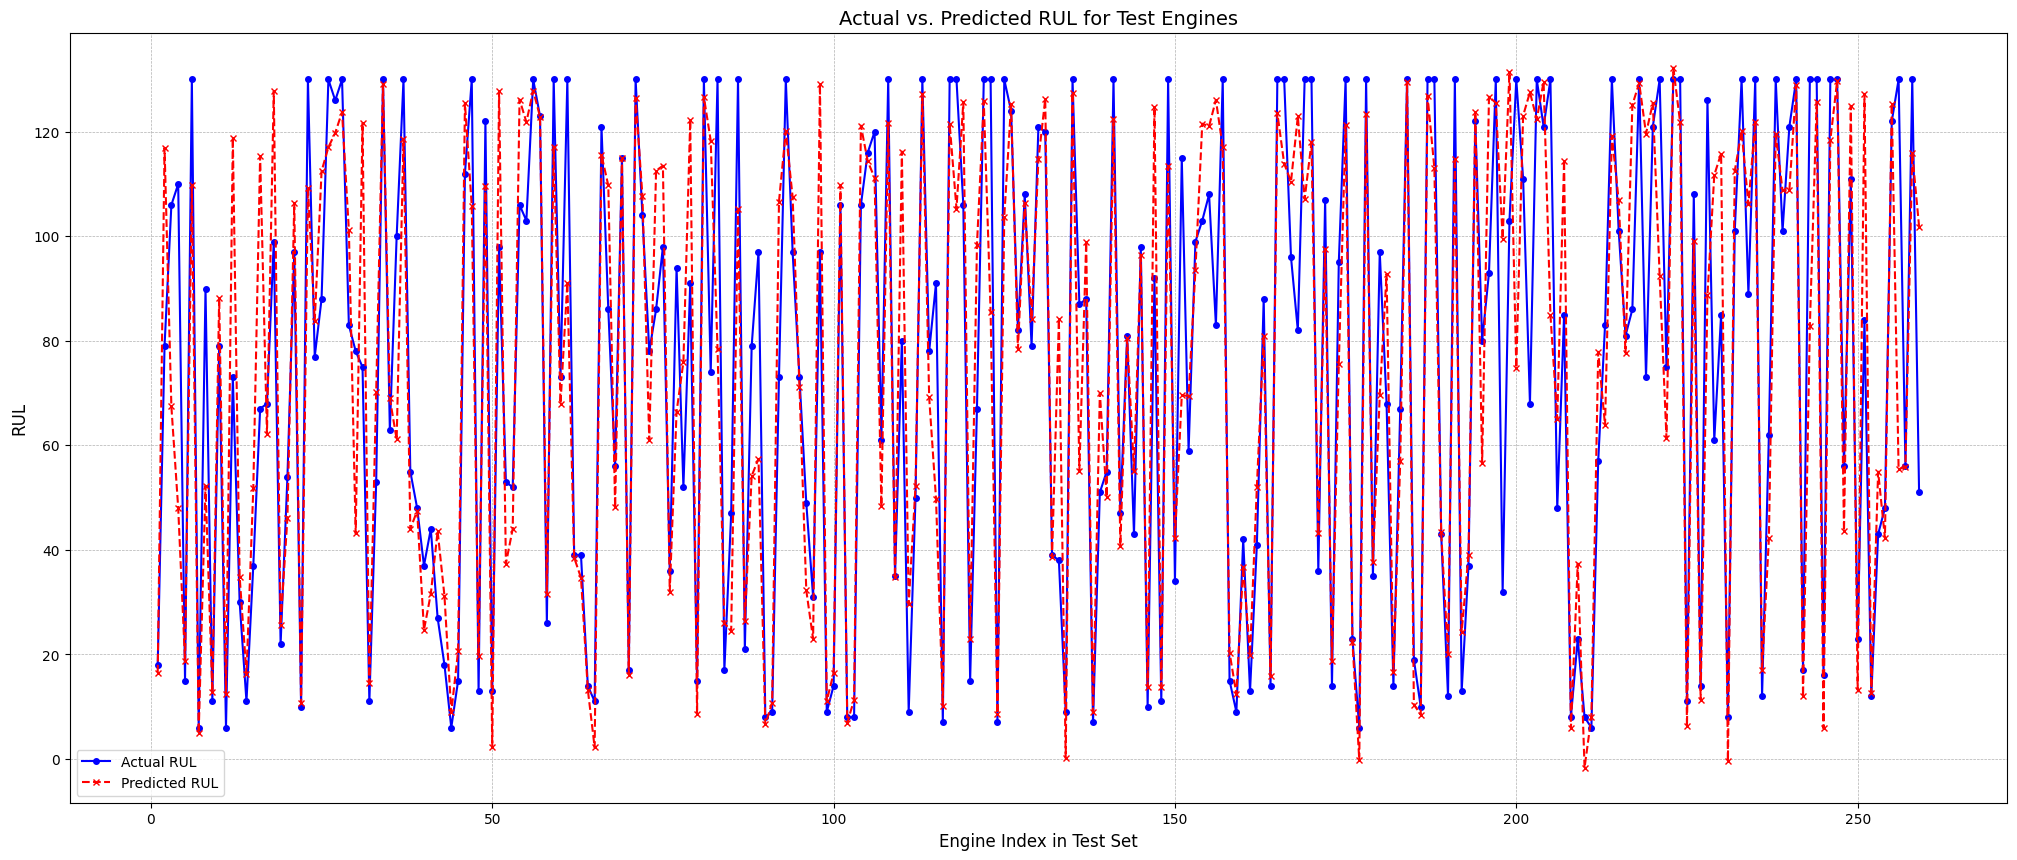

In [49]:
plt.figure(figsize=(25,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=1.5, markersize=4)
plt.plot(range(1,len(y_pred_cycles_kt)+1),y_pred_cycles_kt, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=1.5, markersize=4)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## PCA

In [27]:
def Conv1d_LSTM_pca(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_pca_reshaped.shape[1],x_train_pca_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [64,128]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [64,128])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [28]:
tuner_pca = kt.Hyperband(hypermodel=Conv1d_LSTM_pca,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_pca',
                     overwrite=True
)

In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

tuner_pca.search(
    x_train_pca_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 05m 45s]
val_mse: 0.05455503612756729

Best val_mse So Far: 0.04802429676055908
Total elapsed time: 02h 46m 13s
INFO:tensorflow:Oracle triggered exit


In [30]:
best_hp_pca = tuner_pca.get_best_hyperparameters(num_trials=1)[0]
for keys,values in best_hp_pca.values.items():
    print(f'{keys} : {values}')

num_hidden_layer : 1
dropout_rate : 0.2
n_f1 : 128
k_s1 : 5
n_lstm1 : 64
n_l1 : 50
k_l2 : 0.0
learning_rate : 0.001
n_f2 : 128
k_s2 : 5
n_lstm2 : 64
n_l2 : 100
tuner/epochs : 70
tuner/initial_epoch : 0
tuner/bracket : 0
tuner/round : 0


In [31]:
model_pca = tuner_pca.hypermodel.build(best_hp_pca)
model_pca.fit(x_train_pca_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 10s 13ms/step - loss: 0.1053 - mse: 0.1053 - val_loss: 0.0703 - val_mse: 0.0703 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 8s 13ms/step - loss: 0.0573 - mse: 0.0573 - val_loss: 0.0604 - val_mse: 0.0604 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 7s 12ms/step - loss: 0.0434 - mse: 0.0434 - val_loss: 0.0487 - val_mse: 0.0487 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 7s 11ms/step - loss: 0.0383 - mse: 0.0383 - val_loss: 0.0552 - val_mse: 0.0552 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 8s 13ms/step - loss: 0.0311 - mse: 0.0311 - val_loss: 0.0657 - val_mse: 0.0657 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 8s 14ms/step - loss: 0.0258 - mse: 0.0258 - val_loss: 0.0650 - val_mse: 0.0650 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 10s 16ms/step - loss: 0.0194 - mse: 0.0194 - val_loss: 0.0568 - val_m

In [32]:
model_pca.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 30, 128)           2048      
                                                                 
 re_lu_4 (ReLU)              (None, 30, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 64)            49408     
                                                                 
 dropout_4 (Dropout)         (None, 30, 64)            0         
                                                                 
 global_average_pooling1d_1   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_3 (Dense)             (None, 50)                3250      
                                                      

In [34]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_pca = model_pca.predict(x_test_pca_reshaped)
y_pred_cycles_kt_pca = y_pred_norm_kt_pca * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_pca = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_pca))
print(f'Test RMSE (cycles)-pca: {rmse_cycles_pca:.2f}')

9/9 [==============================] - 1s 9ms/step
Test RMSE (cycles)-pca: 26.87


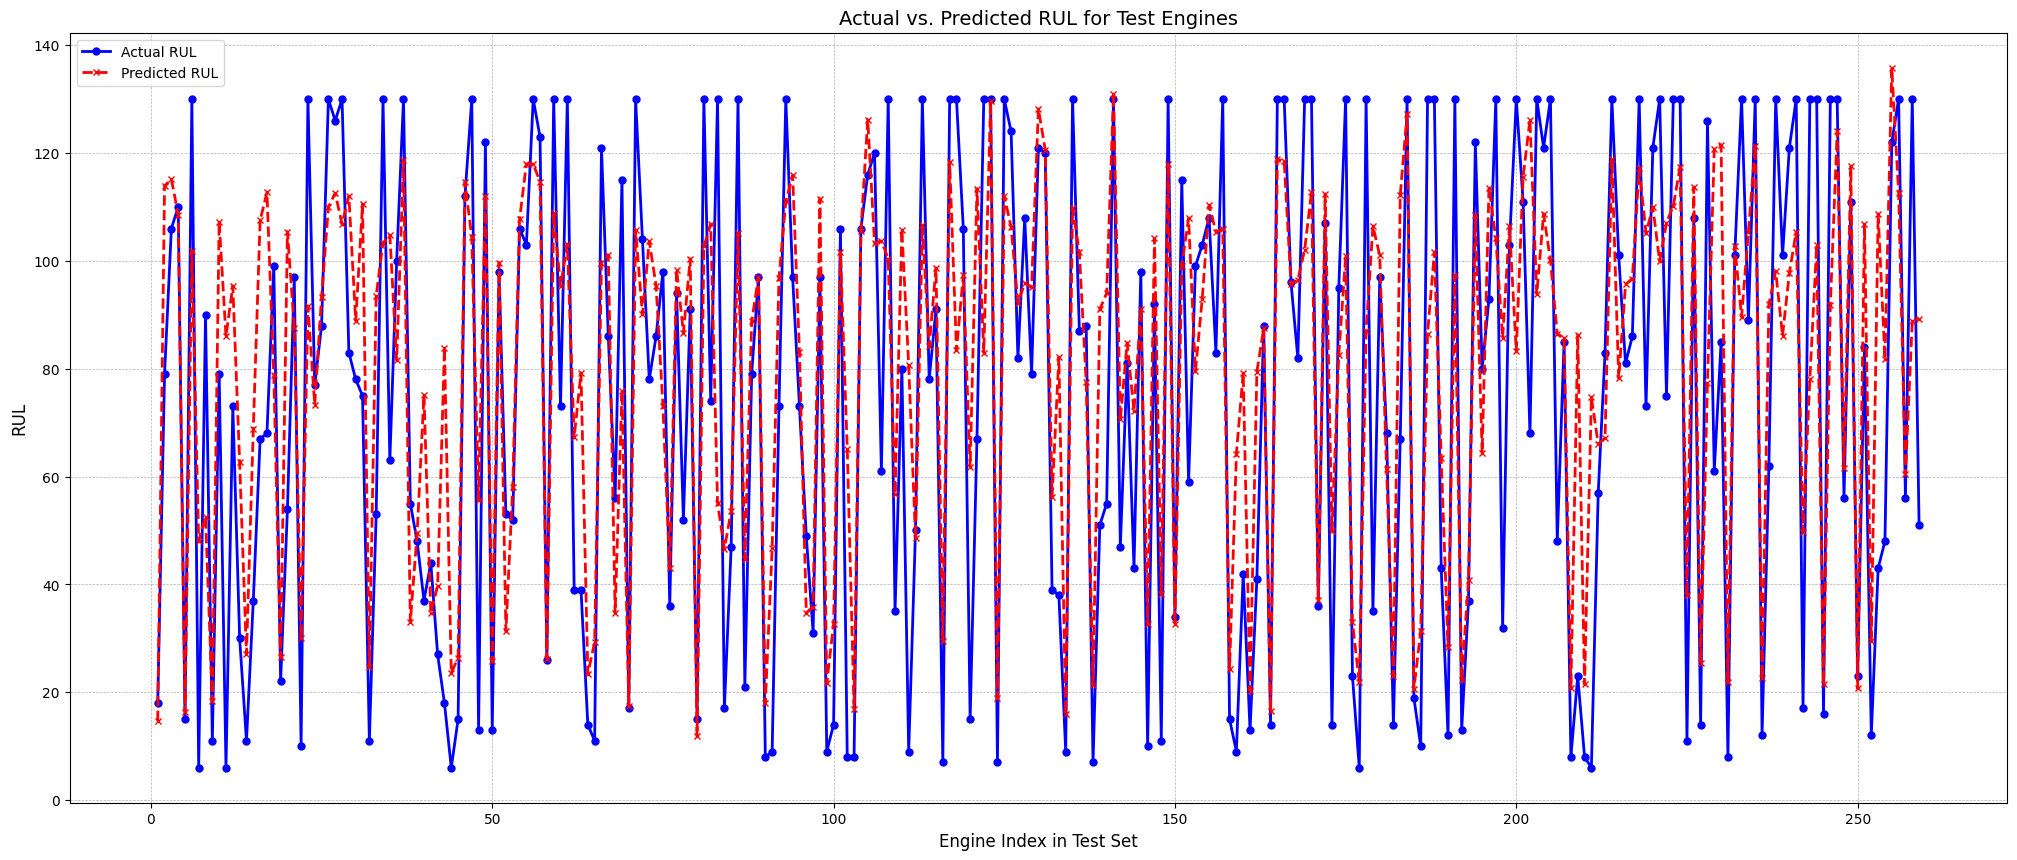

In [36]:
plt.figure(figsize=(25,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=5)
plt.plot(range(1,len(y_pred_cycles_kt_pca)+1),y_pred_cycles_kt_pca, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=5)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Selected features based on Correlation

In [37]:
def Conv1d_LSTM_corr(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_Corr_reshaped.shape[1],x_train_Corr_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [64,128]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [64,128])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [ ]:
tuner_corr = kt.Hyperband(hypermodel=Conv1d_LSTM_corr,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_corr',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

In [39]:
tuner_corr.search(
    x_train_Corr_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 05m 08s]
val_mse: 0.0377032533288002

Best val_mse So Far: 0.029460106045007706
Total elapsed time: 02h 48m 03s
INFO:tensorflow:Oracle triggered exit


In [40]:
best_hp_corr = tuner_corr.get_best_hyperparameters(num_trials=1)[0]
for keys,values in best_hp_corr.values.items():
    print(f'{keys} : {values}')

num_hidden_layer : 1
dropout_rate : 0.1
n_f1 : 64
k_s1 : 5
n_lstm1 : 64
n_l1 : 100
k_l2 : 0.0
learning_rate : 0.001
n_f2 : 128
k_s2 : 5
n_lstm2 : 64
n_l2 : 50
tuner/epochs : 24
tuner/initial_epoch : 0
tuner/bracket : 1
tuner/round : 0


In [42]:
model_corr = tuner_corr.hypermodel.build(best_hp_corr)
model_corr.fit(x_train_Corr_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 9s 12ms/step - loss: 0.0907 - mse: 0.0907 - val_loss: 0.0559 - val_mse: 0.0559 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 7s 11ms/step - loss: 0.0508 - mse: 0.0508 - val_loss: 0.0365 - val_mse: 0.0365 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 7s 11ms/step - loss: 0.0412 - mse: 0.0412 - val_loss: 0.0475 - val_mse: 0.0475 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 7s 12ms/step - loss: 0.0364 - mse: 0.0364 - val_loss: 0.0340 - val_mse: 0.0340 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 7s 12ms/step - loss: 0.0351 - mse: 0.0351 - val_loss: 0.0344 - val_mse: 0.0344 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 8s 13ms/step - loss: 0.0341 - mse: 0.0341 - val_loss: 0.0330 - val_mse: 0.0330 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 8s 12ms/step - loss: 0.0332 - mse: 0.0332 - val_loss: 0.0350 - val_mse

In [43]:
model_corr.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 30, 64)            2624      
                                                                 
 re_lu_6 (ReLU)              (None, 30, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 30, 64)            33024     
                                                                 
 dropout_6 (Dropout)         (None, 30, 64)            0         
                                                                 
 global_average_pooling1d_2   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_5 (Dense)             (None, 100)               6500      
                                                      

In [45]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_corr = model_corr.predict(x_test_Corr_reshaped)
y_pred_cycles_kt_corr = y_pred_norm_kt_corr * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_corr = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_corr))
print(f'Test RMSE (cycles)-corr: {rmse_cycles_corr:.2f}')

9/9 [==============================] - 0s 9ms/step
Test RMSE (cycles)-corr: 19.35


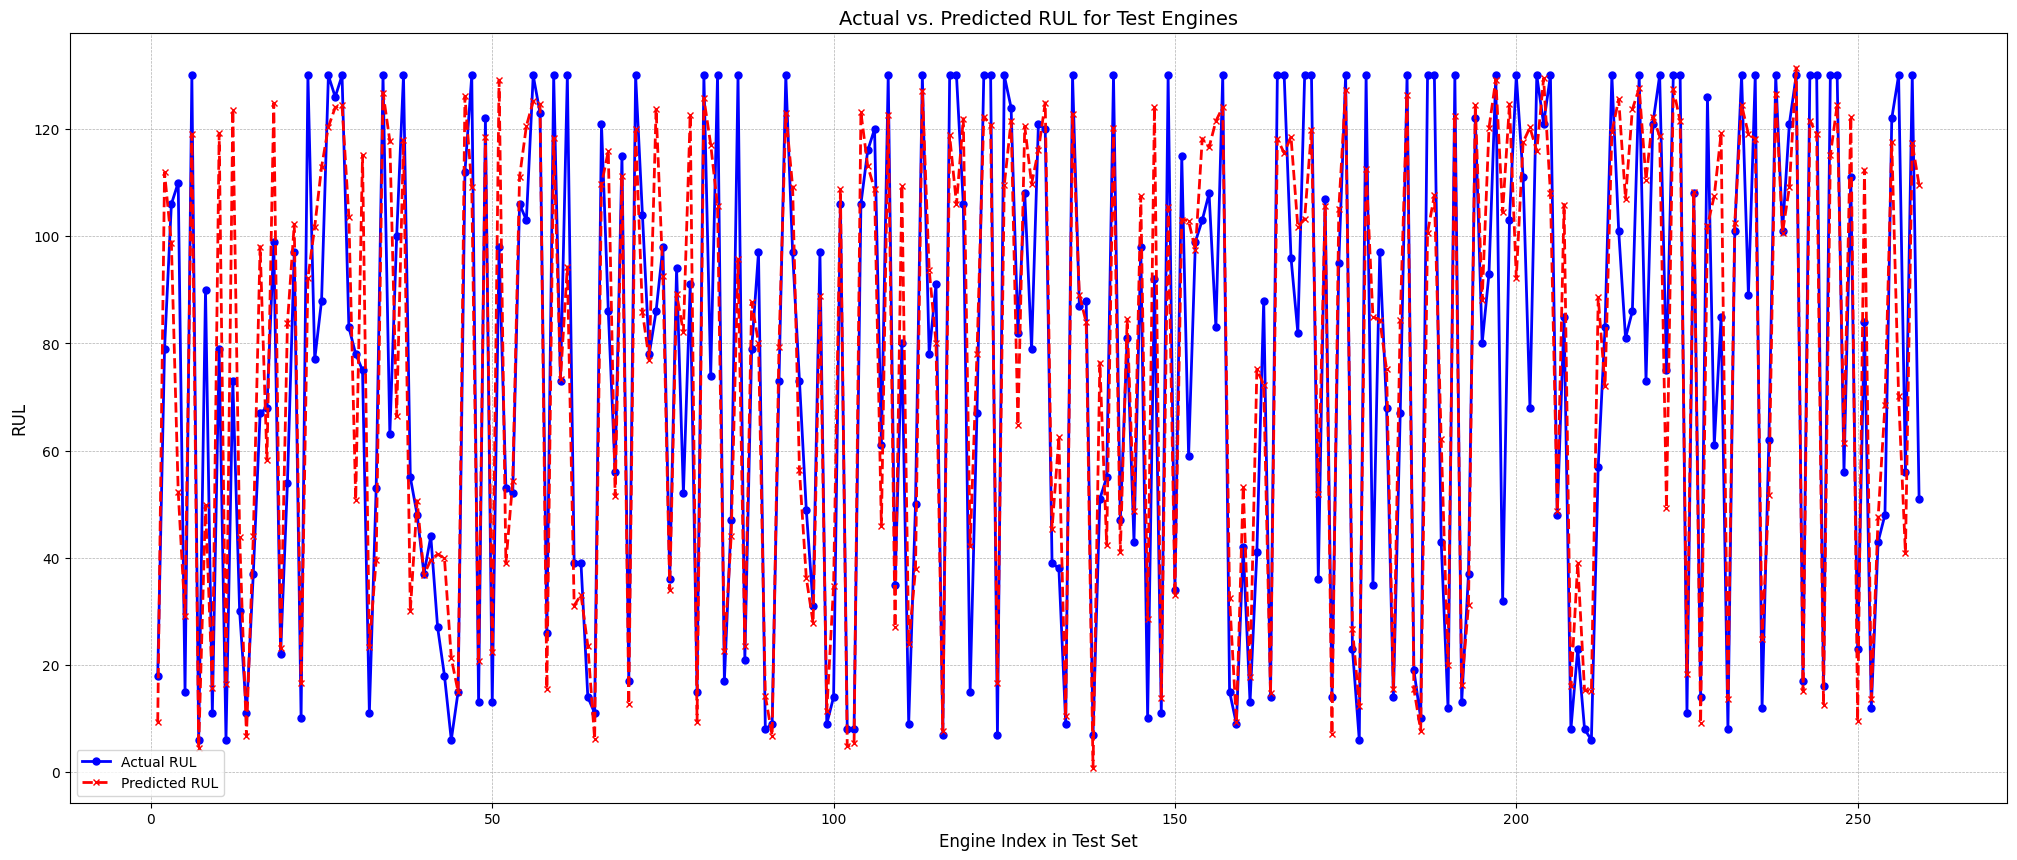

In [46]:
plt.figure(figsize=(25,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=5)
plt.plot(range(1,len(y_pred_cycles_kt_corr)+1),y_pred_cycles_kt_corr, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=5)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Original Data

In [26]:
def Conv1d_LSTM_originaldata(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [64,128]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [64,128])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [28]:
tuner_originaldata = kt.Hyperband(hypermodel=Conv1d_LSTM_originaldata,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_originaldata',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

In [29]:
tuner_originaldata.search(
    x_train_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 03m 59s]
val_mse: 0.03342197835445404

Best val_mse So Far: 0.028487615287303925
Total elapsed time: 02h 35m 29s
INFO:tensorflow:Oracle triggered exit


In [31]:
best_hp_originaldata = tuner_originaldata.get_best_hyperparameters(num_trials=1)[0]
for keys,values in best_hp_originaldata.values.items():
    print(f'{keys} : {values}')

num_hidden_layer : 1
dropout_rate : 0.2
n_f1 : 64
k_s1 : 5
n_lstm1 : 64
n_l1 : 100
k_l2 : 0.0
learning_rate : 0.001
n_f2 : 128
k_s2 : 5
n_lstm2 : 128
n_l2 : 50
tuner/epochs : 70
tuner/initial_epoch : 24
tuner/bracket : 1
tuner/round : 1
tuner/trial_id : 61d6a2998aba367bc1a5134b397d392a


In [32]:
model_originaldata = tuner_originaldata.hypermodel.build(best_hp_originaldata)
model_originaldata.fit(x_train_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 10s 13ms/step - loss: 0.0848 - mse: 0.0848 - val_loss: 0.0500 - val_mse: 0.0500 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 8s 13ms/step - loss: 0.0524 - mse: 0.0524 - val_loss: 0.0420 - val_mse: 0.0420 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 9s 14ms/step - loss: 0.0420 - mse: 0.0420 - val_loss: 0.0386 - val_mse: 0.0386 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 9s 14ms/step - loss: 0.0365 - mse: 0.0365 - val_loss: 0.0342 - val_mse: 0.0342 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 10s 17ms/step - loss: 0.0347 - mse: 0.0347 - val_loss: 0.0342 - val_mse: 0.0342 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 10s 16ms/step - loss: 0.0324 - mse: 0.0324 - val_loss: 0.0372 - val_mse: 0.0372 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 9s 15ms/step - loss: 0.0308 - mse: 0.0308 - val_loss: 0.0491 - val_

In [33]:
model_originaldata.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 30, 64)            7744      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 64)            33024     
                                                                 
 dropout_2 (Dropout)         (None, 30, 64)            0         
                                                                 
 global_average_pooling1d_1   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_2 (Dense)             (None, 100)               6500      
                                                      

In [34]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_originaldata = model_originaldata.predict(x_test_reshaped)
y_pred_cycles_kt_originaldata = y_pred_norm_kt_originaldata * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_originaldata = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_originaldata))
print(f'Test RMSE (cycles)- original data: {rmse_cycles_originaldata:.2f}')

9/9 [==============================] - 1s 8ms/step
Test RMSE (cycles)- original data: 20.28


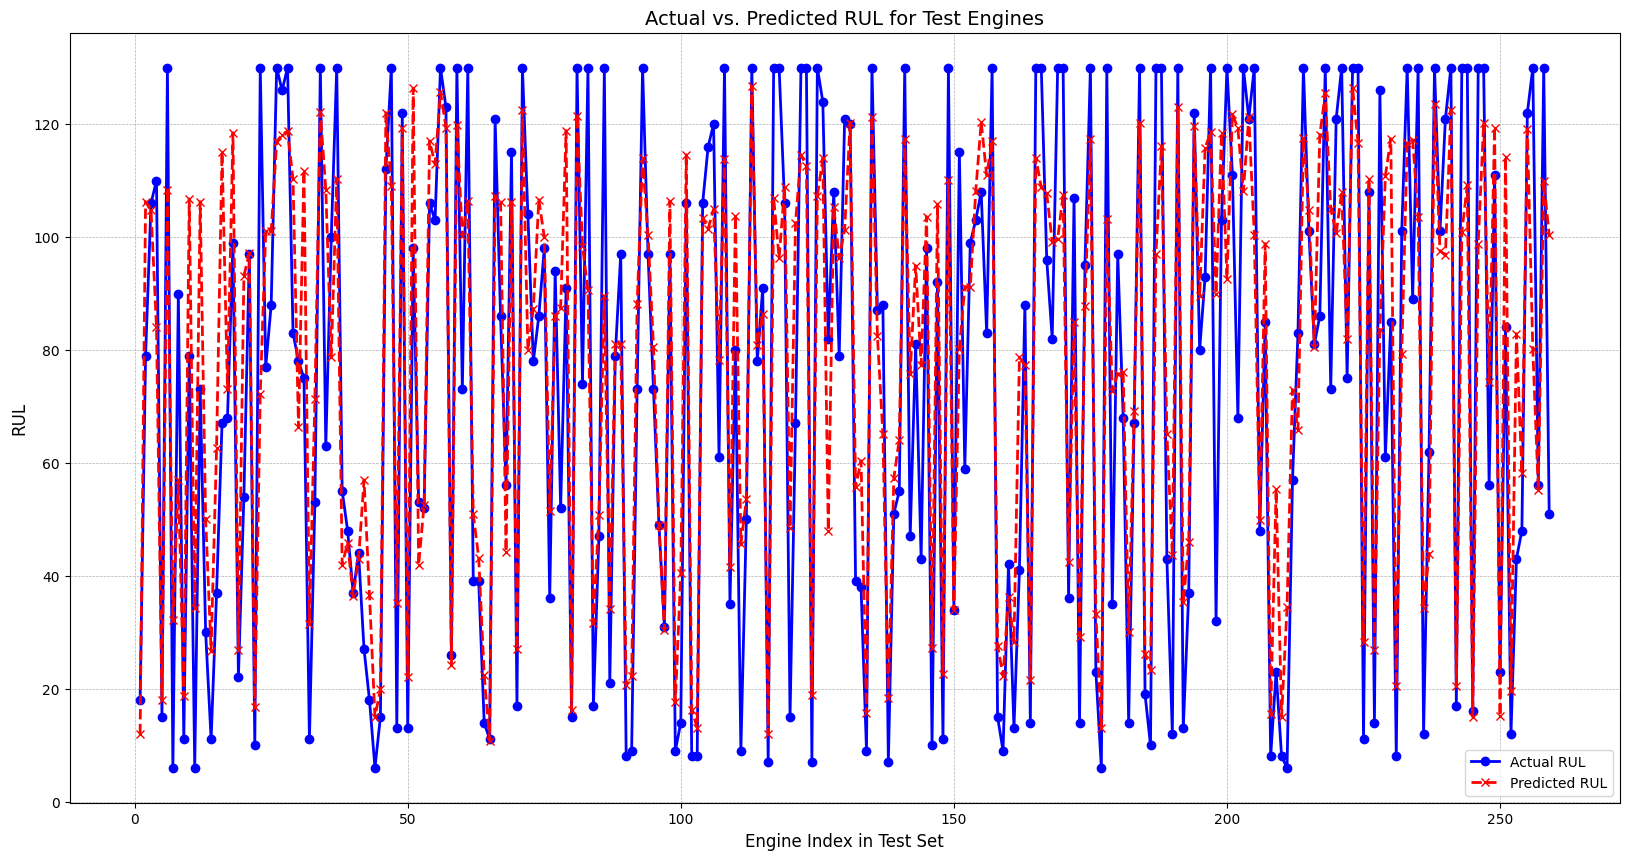

In [37]:
plt.figure(figsize=(20,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_originaldata)+1),y_pred_cycles_kt_originaldata, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Selected Features based on Correlation 

In [ ]:
def Conv1d_LSTM_2ndedition_corr(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_Corr_reshaped.shape[1],x_train_Corr_reshaped.shape[2])))

    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    
    model.add(Conv1D(filters=hp.Choice('n_f1', [64,128]), kernel_size=hp.Choice('k_s1',[3,5]), padding='same'))
    model.add(ReLU())
    model.add(AveragePooling1D(pool_size=hp.Choice('p_s1',[2,3]), strides=1 , padding='valid'))

    model.add(Conv1D(filters=hp.Choice('n_f2', [32,64,128]), kernel_size=hp.Choice('k_s2',[3,5]), padding='same'))
    model.add(ReLU())
    model.add(AveragePooling1D(pool_size=hp.Choice('p_s2',[2,3]),strides=1 , padding='valid'))

    model.add(LSTM(units=hp.Choice('n_lstm1', [64,128,256]), return_sequences=True))
    model.add(Dropout(dropout_rate))

    model.add(LSTM(units=hp.Choice('n_lstm2', [32,64,128]), return_sequences=False))
    model.add(Dropout(dropout_rate))

    model.add(Dense(units=hp.Choice('n_l1', [50,70,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    model.add(ReLU())
    model.add(Dropout(dropout_rate))


    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [2e-4])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [47]:
tuner_corr_2ndedition = kt.Hyperband(hypermodel=Conv1d_LSTM_2ndedition_corr,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_corr_2ndedition',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5,  min_lr=1e-5)

In [48]:
tuner_corr_2ndedition.search(
    x_train_Corr_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 10m 34s]
val_mse: 0.02510075643658638

Best val_mse So Far: 0.02464321255683899
Total elapsed time: 03h 53m 56s
INFO:tensorflow:Oracle triggered exit


In [49]:
best_hp_corr_2ndedition = tuner_corr_2ndedition.get_best_hyperparameters(num_trials=1)[0]
for keys, values in best_hp_corr_2ndedition.values.items():
    print(keys,values)

dropout_rate 0.2
n_f1 64
k_s1 3
p_s1 2
n_f2 128
k_s2 3
p_s2 2
n_lstm1 64
n_lstm2 32
n_l1 70
k_l2 0.1
learning_rate 0.0002
tuner/epochs 70
tuner/initial_epoch 24
tuner/bracket 1
tuner/round 1
tuner/trial_id c74c45dd18faa7f60382797a2e34852b


In [50]:
model_corr_2ndedition = tuner_corr_2ndedition.hypermodel.build(best_hp_corr_2ndedition)
model_corr_2ndedition.fit(x_train_Corr_reshaped,y_train_reshaped,validation_split=0.15,epochs=70,batch_size=64, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 15s 19ms/step - loss: 2.3791 - mse: 0.1162 - val_loss: 0.9555 - val_mse: 0.0678 - lr: 2.0000e-04
Epoch 2/70
614/614 [==============================] - 11s 18ms/step - loss: 0.4647 - mse: 0.0643 - val_loss: 0.1660 - val_mse: 0.0439 - lr: 2.0000e-04
Epoch 3/70
614/614 [==============================] - 11s 18ms/step - loss: 0.0944 - mse: 0.0472 - val_loss: 0.0492 - val_mse: 0.0384 - lr: 2.0000e-04
Epoch 4/70
614/614 [==============================] - 11s 18ms/step - loss: 0.0474 - mse: 0.0428 - val_loss: 0.0376 - val_mse: 0.0355 - lr: 2.0000e-04
Epoch 5/70
614/614 [==============================] - 11s 18ms/step - loss: 0.0417 - mse: 0.0401 - val_loss: 0.0373 - val_mse: 0.0357 - lr: 2.0000e-04
Epoch 6/70
614/614 [==============================] - 11s 18ms/step - loss: 0.0407 - mse: 0.0394 - val_loss: 0.0394 - val_mse: 0.0381 - lr: 2.0000e-04
Epoch 7/70
614/614 [==============================] - 11s 18ms/step - loss: 0.0381 - mse: 0.03

In [51]:
model_corr_2ndedition.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 30, 64)            1600      
                                                                 
 re_lu_3 (ReLU)              (None, 30, 64)            0         
                                                                 
 average_pooling1d_2 (Averag  (None, 29, 64)           0         
 ePooling1D)                                                     
                                                                 
 conv1d_3 (Conv1D)           (None, 29, 128)           24704     
                                                                 
 re_lu_4 (ReLU)              (None, 29, 128)           0         
                                                                 
 average_pooling1d_3 (Averag  (None, 28, 128)          0         
 ePooling1D)                                          

In [52]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_corr_2ndedition = model_corr_2ndedition.predict(x_test_Corr_reshaped)
y_pred_cycles_kt_corr_2ndedition = y_pred_norm_kt_corr_2ndedition * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_corr_2ndedition = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_corr_2ndedition))
print(f'Test RMSE (cycles)- corr_2ndedition: {rmse_cycles_corr_2ndedition:.2f}')

9/9 [==============================] - 1s 18ms/step
Test RMSE (cycles)- corr_2ndedition: 20.40


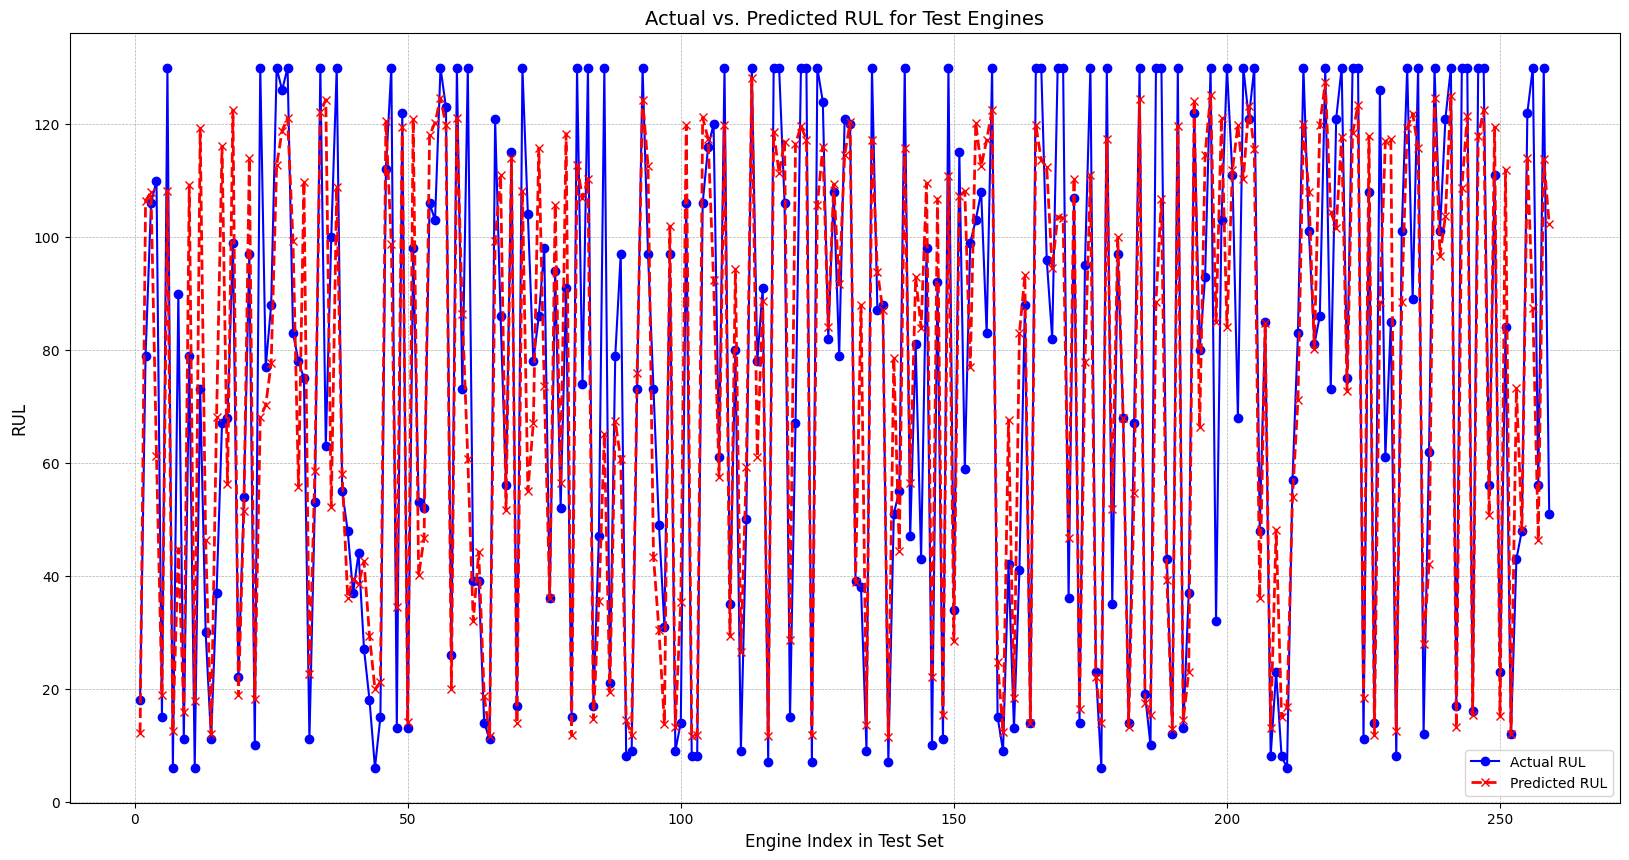

In [53]:
plt.figure(figsize=(20,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle=None, linewidth=None, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_corr_2ndedition)+1),y_pred_cycles_kt_corr_2ndedition, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## AutoEncoder

In [25]:
def create_Conv1D_LSTM_AE (hp):

    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])

    nf_1 = hp.Choice('nf1', [128,64])
    nk_1 = hp.Choice('nk1', [3,5])

    nl_1 = hp.Choice('nl1', [64,32])
    kl2 = hp.Choice('kl2', [0])

    nl_2 = hp.Choice('nl3', [16,8])
    
    # Input Layer
    input_layer = Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2]), name='Input')
    
    # Encoder layers
    encoded = Conv1D(filters=nf_1, kernel_size=nk_1, padding='same', name='Encoder_1')(input_layer)
    encoded = ReLU()(encoded)

    encoded = LSTM(nl_1, return_sequences=True, kernel_regularizer=regularizers.l2(kl2), name='Encoder_2')(encoded)


    bottleneck = LSTM(nl_2, return_sequences=True, name='Bottleneck')(encoded)
    
    # Decoder layers

    decoded = LSTM(nl_1, return_sequences=True, kernel_regularizer=regularizers.l2(kl2), name='Decoder_2')(bottleneck)
    decoded = Dropout(dropout_rate)(decoded)

    decoded = Conv1D(filters=nf_1, kernel_size=nk_1, padding='same', name='Decoder_1')(decoded)
    decoded = ReLU()(decoded)

    output = TimeDistributed(Dense(x_train_reshaped.shape[2], activation='linear', name='Decoder_Output'))(decoded) 
    
    # Full autoencoder model
    deep_autoencoder = Model(input_layer, output)
    deep_autoencoder.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3])), loss='mean_squared_error', metrics=['mse'])
    return deep_autoencoder

In [33]:
tuner_AE = kt.Hyperband(hypermodel=create_Conv1D_LSTM_AE,
                     objective='val_mse',    
                     max_epochs=50,
                     factor=3,                
                     hyperband_iterations=1,
                     seed = 42,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_AE',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5,  min_lr=1e-4)

In [34]:
tuner_AE.search(
    x_train_reshaped,
    x_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 32 Complete [00h 00m 31s]
val_mse: 0.0006896777777001262

Best val_mse So Far: 0.0004504947573877871
Total elapsed time: 00h 17m 47s
INFO:tensorflow:Oracle triggered exit


In [35]:
best_hp_AE = tuner_AE.get_best_hyperparameters(num_trials=1)[0]
for keys, values in best_hp_AE.values.items():
    print(keys,values)

dropout_rate 0.1
nf1 128
nk1 3
nl1 64
kl2 0
nl3 16
learning_rate 0.001
tuner/epochs 2
tuner/initial_epoch 0
tuner/bracket 3
tuner/round 0


In [36]:
model_AE = tuner_AE.hypermodel.build(best_hp_AE)
model_AE.fit(x_train_reshaped,x_train_reshaped,validation_split=0.15,epochs=50,batch_size=64, callbacks=[early_stop,reduce_lr])

Epoch 1/50
614/614 [==============================] - 19s 23ms/step - loss: 0.0259 - mse: 0.0259 - val_loss: 9.2270e-04 - val_mse: 9.2270e-04 - lr: 0.0010
Epoch 2/50
614/614 [==============================] - 14s 22ms/step - loss: 0.0011 - mse: 0.0011 - val_loss: 4.9324e-04 - val_mse: 4.9324e-04 - lr: 0.0010
Epoch 3/50
614/614 [==============================] - 14s 22ms/step - loss: 6.7916e-04 - mse: 6.7916e-04 - val_loss: 3.4197e-04 - val_mse: 3.4197e-04 - lr: 0.0010
Epoch 4/50
614/614 [==============================] - 13s 22ms/step - loss: 3.9921e-04 - mse: 3.9921e-04 - val_loss: 1.4811e-04 - val_mse: 1.4811e-04 - lr: 0.0010
Epoch 5/50
614/614 [==============================] - 13s 22ms/step - loss: 2.4138e-04 - mse: 2.4138e-04 - val_loss: 1.1343e-04 - val_mse: 1.1343e-04 - lr: 0.0010
Epoch 6/50
614/614 [==============================] - 14s 22ms/step - loss: 1.8971e-04 - mse: 1.8971e-04 - val_loss: 1.1259e-04 - val_mse: 1.1259e-04 - lr: 0.0010
Epoch 7/50
614/614 [==================

In [37]:
model_AE.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 30, 24)]          0         
                                                                 
 Encoder_1 (Conv1D)          (None, 30, 128)           9344      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 128)           0         
                                                                 
 Encoder_2 (LSTM)            (None, 30, 64)            49408     
                                                                 
 Bottleneck (LSTM)           (None, 30, 16)            5184      
                                                                 
 Decoder_2 (LSTM)            (None, 30, 64)            20736     
                                                                 
 dropout_1 (Dropout)         (None, 30, 64)            0   

In [38]:
bottleneck_layer = model_AE.get_layer('Bottleneck')
Encoder_Model = Model(inputs=model_AE.input, outputs=bottleneck_layer.output)
Encoder_Model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 30, 24)]          0         
                                                                 
 Encoder_1 (Conv1D)          (None, 30, 128)           9344      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 128)           0         
                                                                 
 Encoder_2 (LSTM)            (None, 30, 64)            49408     
                                                                 
 Bottleneck (LSTM)           (None, 30, 16)            5184      
                                                                 
Total params: 63,936
Trainable params: 63,936
Non-trainable params: 0
_________________________________________________________________


In [39]:
x_train_encoder_reshaped = Encoder_Model.predict(x_train_reshaped)
x_test_encoder_reshaped = Encoder_Model.predict(x_test_reshaped)
print('(Num of Train Samples, Time Steps, Num of Features)-AE : {}'.format(x_train_encoder_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-AE : {}\n'.format(x_test_encoder_reshaped.shape))


9/9 [==============================] - 0s 5ms/step
(Num of Train Samples, Time Steps, Num of Features)-AE : (46219, 30, 16)
(Num of Test Samples, Time Steps, Num of Features)-AE : (259, 30, 16)



## Encoder (Non Trainable) + Conv1D + LSTM + Dense

In [41]:
Encoder_weights = Encoder_Model.get_weights()

In [42]:
Encoder_Model_NonTrainable = keras.models.clone_model(Encoder_Model)
Encoder_Model_NonTrainable.set_weights(Encoder_Model.get_weights())

for layer in Encoder_Model_NonTrainable.layers:
    layer.trainable = False

In [43]:
def Conv1d_LSTM_EncoderData(hp):  

    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))
    model.add(Encoder_Model_NonTrainable)
    
    #num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Float('dropout_rate', 0, 0.21, step=0.1)
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [32,64,128]), kernel_size=hp.Choice('k_s1',[3,5,7]), padding='same'))
    model.add(ReLU())

#    if num_hidden_layer == 2:
#        n_f2 = hp.Choice('n_f2', [128,64])
#        k_s2 = hp.Choice('k_s2',[5])
#        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
#        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [32,64,128]), return_sequences=True))
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_lstm2 = hp.Choice('n_lstm2', [64,128])
#        model.add(LSTM(units=n_lstm2, return_sequences=True))
#        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,70,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_l2 = hp.Choice('n_l2', [50,100,125])
#        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
#        model.add(Dense(units=n_l2, activation=None, 
#                        kernel_regularizer=regularizers.L2(k_l2)))
#        model.add(ReLU())
#        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3,3e-5])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [44]:
tuner_encoderdata = kt.Hyperband(hypermodel=Conv1d_LSTM_EncoderData,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_Encoderdata',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

In [45]:
tuner_encoderdata.search(
    x_train_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 11m 26s]
val_mse: 0.058860328048467636

Best val_mse So Far: 0.05288652330636978
Total elapsed time: 03h 02m 11s
INFO:tensorflow:Oracle triggered exit


In [46]:
best_hp_encoderdata = tuner_encoderdata.get_best_hyperparameters(num_trials=1)[0]
for keys,values in best_hp_encoderdata.values.items():
    print(f'{keys}: {values}')

dropout_rate: 0.2
n_f1: 128
k_s1: 7
n_lstm1: 128
n_l1: 70
k_l2: 0.1
learning_rate: 0.001
tuner/epochs: 24
tuner/initial_epoch: 8
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 4d3eca8eeef360d8fce5dd6cc2b90481


In [47]:
model_encoderdata = tuner_encoderdata.hypermodel.build(best_hp_encoderdata)
model_encoderdata.fit(x_train_reshaped,y_train_reshaped,validation_split=0.15,epochs=70,batch_size=64, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 16s 19ms/step - loss: 0.8556 - mse: 0.0888 - val_loss: 0.0651 - val_mse: 0.0624 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 10s 17ms/step - loss: 0.0694 - mse: 0.0668 - val_loss: 0.0621 - val_mse: 0.0598 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 11s 17ms/step - loss: 0.0649 - mse: 0.0629 - val_loss: 0.0631 - val_mse: 0.0616 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 10s 16ms/step - loss: 0.0635 - mse: 0.0615 - val_loss: 0.0568 - val_mse: 0.0547 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 10s 17ms/step - loss: 0.0610 - mse: 0.0591 - val_loss: 0.0579 - val_mse: 0.0560 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 10s 17ms/step - loss: 0.0576 - mse: 0.0558 - val_loss: 0.0604 - val_mse: 0.0582 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 10s 17ms/step - loss: 0.0530 - mse: 0.0509 - val_loss: 0.0681 - 

In [48]:
model_encoderdata.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_2 (Functional)        (None, 30, 16)            63936     
                                                                 
 conv1d_1 (Conv1D)           (None, 30, 128)           14464     
                                                                 
 re_lu_2 (ReLU)              (None, 30, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           131584    
                                                                 
 dropout_2 (Dropout)         (None, 30, 128)           0         
                                                                 
 global_average_pooling1d_1   (None, 128)              0         
 (GlobalAveragePooling1D)                                        
                                                      

In [49]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_encoderdata = model_encoderdata.predict(x_test_reshaped)
y_pred_cycles_kt_encoderdata = y_pred_norm_kt_encoderdata * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_encoderdata = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_encoderdata))
print(f'Test RMSE (cycles) AE-NN: {rmse_cycles_encoderdata:.2f}')

9/9 [==============================] - 2s 20ms/step
Test RMSE (cycles) AE-NN: 29.21


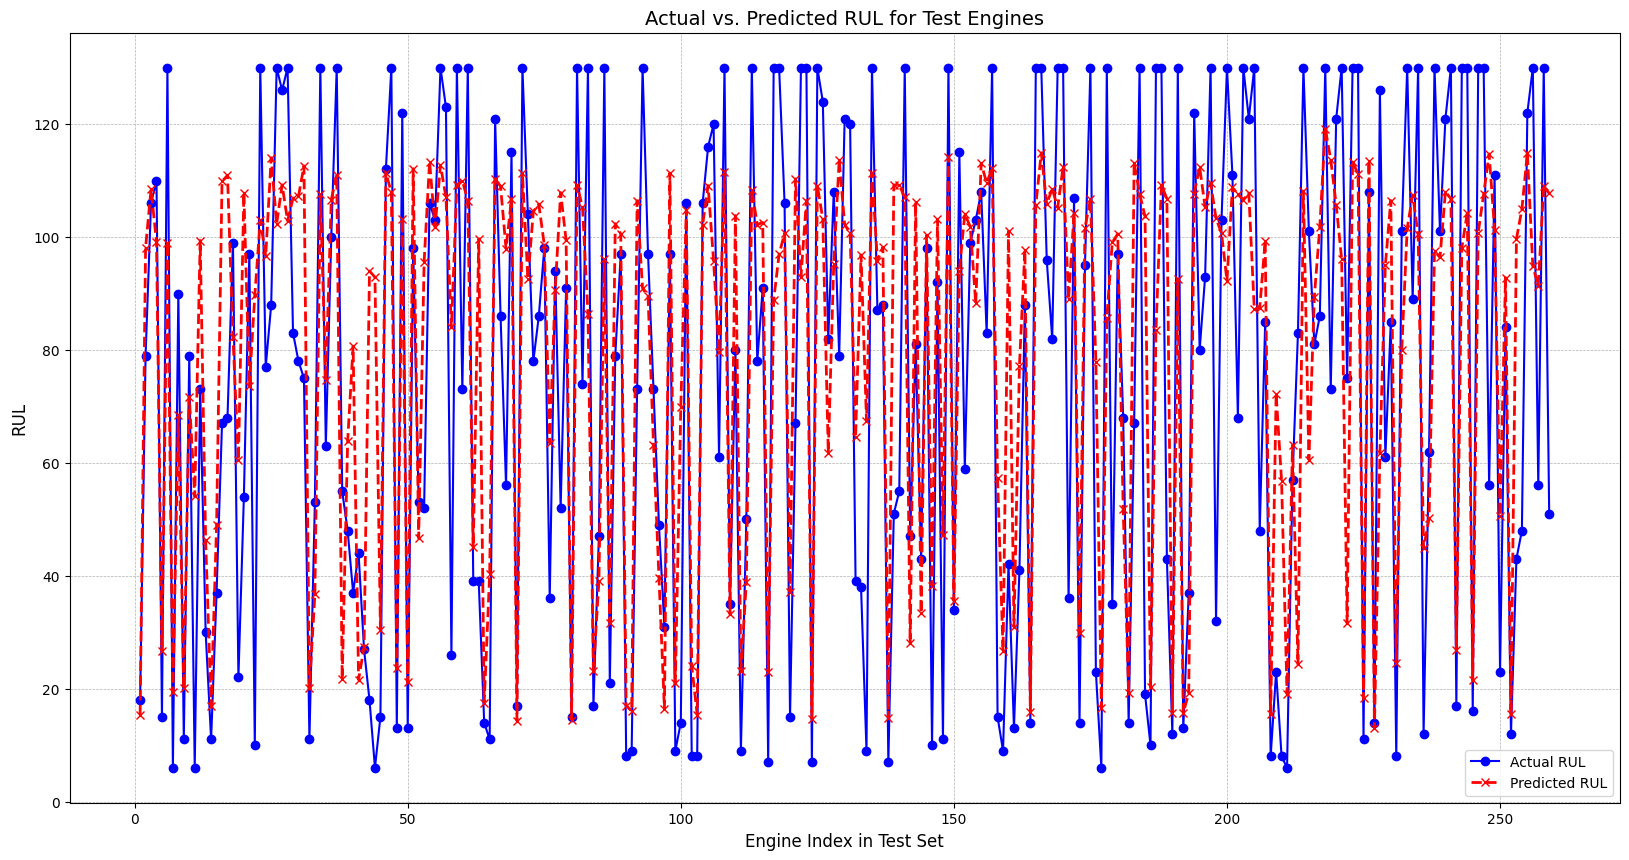

In [50]:
plt.figure(figsize=(20,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle=None, linewidth=None, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_encoderdata)+1),y_pred_cycles_kt_encoderdata, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Encoder (Trainable) + Conv1D + LSTM + Dense

In [51]:
Encoder_Model_Trainable_LSTM = keras.models.clone_model(Encoder_Model)
Encoder_Model_Trainable_LSTM.set_weights(Encoder_Model.get_weights())

In [52]:
def Conv1d_LSTM_Encoder(hp):  

    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))
    model.add(Encoder_Model_Trainable_LSTM)
    
    #num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Float('dropout_rate', 0, 0.21, step=0.1)
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [32,64,128]), kernel_size=hp.Choice('k_s1',[3,5,7]), padding='same'))
    model.add(ReLU())

#    if num_hidden_layer == 2:
#        n_f2 = hp.Choice('n_f2', [128,64])
#        k_s2 = hp.Choice('k_s2',[5])
#        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
#        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [32,64,128]), return_sequences=True))
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_lstm2 = hp.Choice('n_lstm2', [64,128])
#        model.add(LSTM(units=n_lstm2, return_sequences=True))
#        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,70,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_l2 = hp.Choice('n_l2', [50,100,125])
#        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
#        model.add(Dense(units=n_l2, activation=None, 
#                        kernel_regularizer=regularizers.L2(k_l2)))
#        model.add(ReLU())
#        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3,3e-5])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [53]:
tuner_NNencoder = kt.Hyperband(hypermodel=Conv1d_LSTM_Encoder,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs_FD2',
                     project_name='conv1d_lstm_hb_NNEncoder',
                     overwrite=True
)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

In [54]:
tuner_NNencoder.search(
    x_train_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 06m 37s]
val_mse: 0.033669888973236084

Best val_mse So Far: 0.021479453891515732
Total elapsed time: 03h 52m 53s
INFO:tensorflow:Oracle triggered exit


In [55]:
best_hp_NNencoder = tuner_NNencoder.get_best_hyperparameters(num_trials=1)[0]
for keys, values in best_hp_NNencoder.values.items():
    print(keys,values)

dropout_rate 0.0
n_f1 64
k_s1 7
n_lstm1 32
n_l1 100
k_l2 0.0
learning_rate 0.001
tuner/epochs 3
tuner/initial_epoch 0
tuner/bracket 3
tuner/round 0


In [56]:
model_NNencoder = tuner_NNencoder.hypermodel.build(best_hp_NNencoder)
model_NNencoder.fit(x_train_reshaped,y_train_reshaped,validation_split=0.15,epochs=70,batch_size=64, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 19s 23ms/step - loss: 0.0039 - mse: 0.0039 - val_loss: 0.0349 - val_mse: 0.0349 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 14s 22ms/step - loss: 9.2307e-05 - mse: 9.2307e-05 - val_loss: 0.0350 - val_mse: 0.0350 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 14s 22ms/step - loss: 8.3142e-05 - mse: 8.3142e-05 - val_loss: 0.0357 - val_mse: 0.0357 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 14s 22ms/step - loss: 9.0676e-05 - mse: 9.0676e-05 - val_loss: 0.0351 - val_mse: 0.0351 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 14s 22ms/step - loss: 1.6498e-04 - mse: 1.6498e-04 - val_loss: 0.0327 - val_mse: 0.0327 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 14s 22ms/step - loss: 2.9852e-04 - mse: 2.9852e-04 - val_loss: 0.0348 - val_mse: 0.0348 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 13s 22ms/step - loss: 1.

In [57]:
model_NNencoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_2 (Functional)        (None, 30, 16)            63936     
                                                                 
 conv1d_1 (Conv1D)           (None, 30, 64)            7232      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 32)            12416     
                                                                 
 dropout_2 (Dropout)         (None, 30, 32)            0         
                                                                 
 global_average_pooling1d_1   (None, 32)               0         
 (GlobalAveragePooling1D)                                        
                                                      

In [58]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_NNencoder = model_NNencoder.predict(x_test_reshaped)
y_pred_cycles_kt_NNencoder = y_pred_norm_kt_NNencoder * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_NNencoder = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_NNencoder))
print(f'Test RMSE (cycles) AE-NN: {rmse_cycles_NNencoder:.2f}')

9/9 [==============================] - 1s 11ms/step
Test RMSE (cycles) AE-NN: 21.87


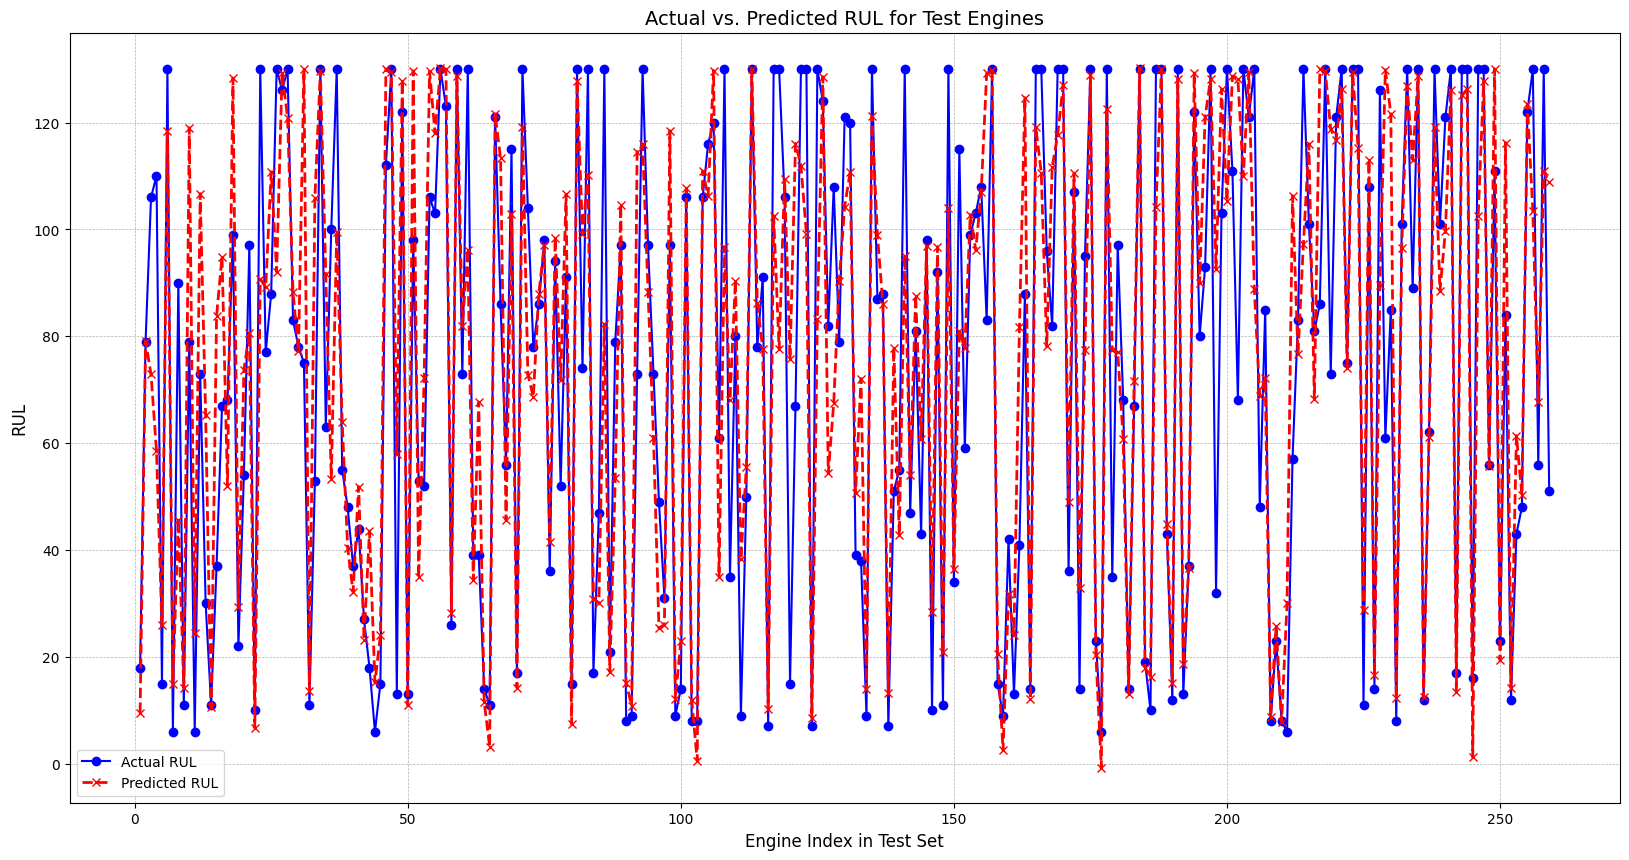

In [59]:
plt.figure(figsize=(20,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle=None, linewidth=None, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_NNencoder)+1),y_pred_cycles_kt_NNencoder, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Encoder (Trainable) + Conv1D + GRU + Dense

In [60]:
Encoder_Model_Trainable_GRU = keras.models.clone_model(Encoder_Model)
Encoder_Model_Trainable_GRU.set_weights(Encoder_Model.get_weights())

In [61]:
def Conv1d_GRU_EncoderData(hp):  

    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))
    model.add(Encoder_Model_Trainable_GRU)
    
    #num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Float('dropout_rate', 0, 0.21, step=0.1)
    

    model.add(Conv1D(filters=hp.Choice('n_f1', [32,64,128]), kernel_size=hp.Choice('k_s1',[3,5,7]), padding='same'))
    model.add(ReLU())

#    if num_hidden_layer == 2:
#        n_f2 = hp.Choice('n_f2', [128,64])
#        k_s2 = hp.Choice('k_s2',[5])
#        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
#        model.add(ReLU())

    model.add(GRU(units=hp.Choice('n_gru', [32,64,128]), return_sequences=True))
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_gru2 = hp.Choice('n_gru2', [64,128])
#        model.add(GRU(units=n_gru2, return_sequences=True))
#        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,70,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

#    if num_hidden_layer == 2:
#        n_l2 = hp.Choice('n_l2', [50,100,125])
#        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
#        model.add(Dense(units=n_l2, activation=None, 
#                        kernel_regularizer=regularizers.L2(k_l2)))
#        model.add(ReLU())
#        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3,3e-5])), loss='mean_squared_error', metrics=['mse'])
    
    return model

In [62]:
tuner_encoderdata_gru = kt.Hyperband(hypermodel=Conv1d_GRU_EncoderData,
                                     objective='val_mse',
                                     max_epochs=70,
                                     factor=3,
                                     hyperband_iterations=1,
                                     directory='./tuner_logs_FD2',
                                     project_name='conv1d_lstm_hb_Encoderdata_GRU',
                                     overwrite=True
)

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

In [63]:
tuner_encoderdata_gru.search(
    x_train_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    epochs=70,
    batch_size=64,
    verbose=2,
    callbacks= [early_stop,reduce_lr]
)

Trial 90 Complete [00h 14m 44s]
val_mse: 0.034303054213523865

Best val_mse So Far: 0.02309514582157135
Total elapsed time: 04h 18m 00s
INFO:tensorflow:Oracle triggered exit


In [64]:
best_hp_NNencoder_gru = tuner_encoderdata_gru.get_best_hyperparameters(num_trials=1)[0]
for keys, values in best_hp_NNencoder_gru.values.items():
    print(keys,values)

dropout_rate 0.1
n_f1 64
k_s1 3
n_gru 128
n_l1 50
k_l2 0.0
learning_rate 0.001
tuner/epochs 3
tuner/initial_epoch 0
tuner/bracket 3
tuner/round 0


In [65]:
model_NNencoder_gru = tuner_encoderdata_gru.hypermodel.build(best_hp_NNencoder_gru)
model_NNencoder_gru.fit(x_train_reshaped,y_train_reshaped,validation_split=0.15,epochs=70,batch_size=64, callbacks=[early_stop,reduce_lr])

Epoch 1/70
614/614 [==============================] - 19s 24ms/step - loss: 0.0053 - mse: 0.0053 - val_loss: 0.0347 - val_mse: 0.0347 - lr: 0.0010
Epoch 2/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0026 - mse: 0.0026 - val_loss: 0.0343 - val_mse: 0.0343 - lr: 0.0010
Epoch 3/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0022 - mse: 0.0022 - val_loss: 0.0348 - val_mse: 0.0348 - lr: 0.0010
Epoch 4/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0018 - mse: 0.0018 - val_loss: 0.0351 - val_mse: 0.0351 - lr: 0.0010
Epoch 5/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0015 - mse: 0.0015 - val_loss: 0.0346 - val_mse: 0.0346 - lr: 0.0010
Epoch 6/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.0346 - val_mse: 0.0346 - lr: 0.0010
Epoch 7/70
614/614 [==============================] - 14s 23ms/step - loss: 0.0010 - mse: 0.0010 - val_loss: 0.0339 - 

In [66]:
model_NNencoder_gru.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_2 (Functional)        (None, 30, 16)            63936     
                                                                 
 conv1d_1 (Conv1D)           (None, 30, 64)            3136      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 64)            0         
                                                                 
 gru_1 (GRU)                 (None, 30, 128)           74496     
                                                                 
 dropout_2 (Dropout)         (None, 30, 128)           0         
                                                                 
 global_average_pooling1d_1   (None, 128)              0         
 (GlobalAveragePooling1D)                                        
                                                      

In [67]:
RUL_max = 130
RUL_min = 0

# Predict y_test and convert back to cycles
y_pred_norm_kt_NNencoder_gru = model_NNencoder_gru.predict(x_test_reshaped)
y_pred_cycles_kt_NNencoder_gru = y_pred_norm_kt_NNencoder_gru * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles_NNencoder_gru = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_NNencoder_gru))
print(f'Test RMSE (cycles) AE-NN: {rmse_cycles_NNencoder_gru:.2f}')

9/9 [==============================] - 1s 18ms/step
Test RMSE (cycles) AE-NN: 20.77


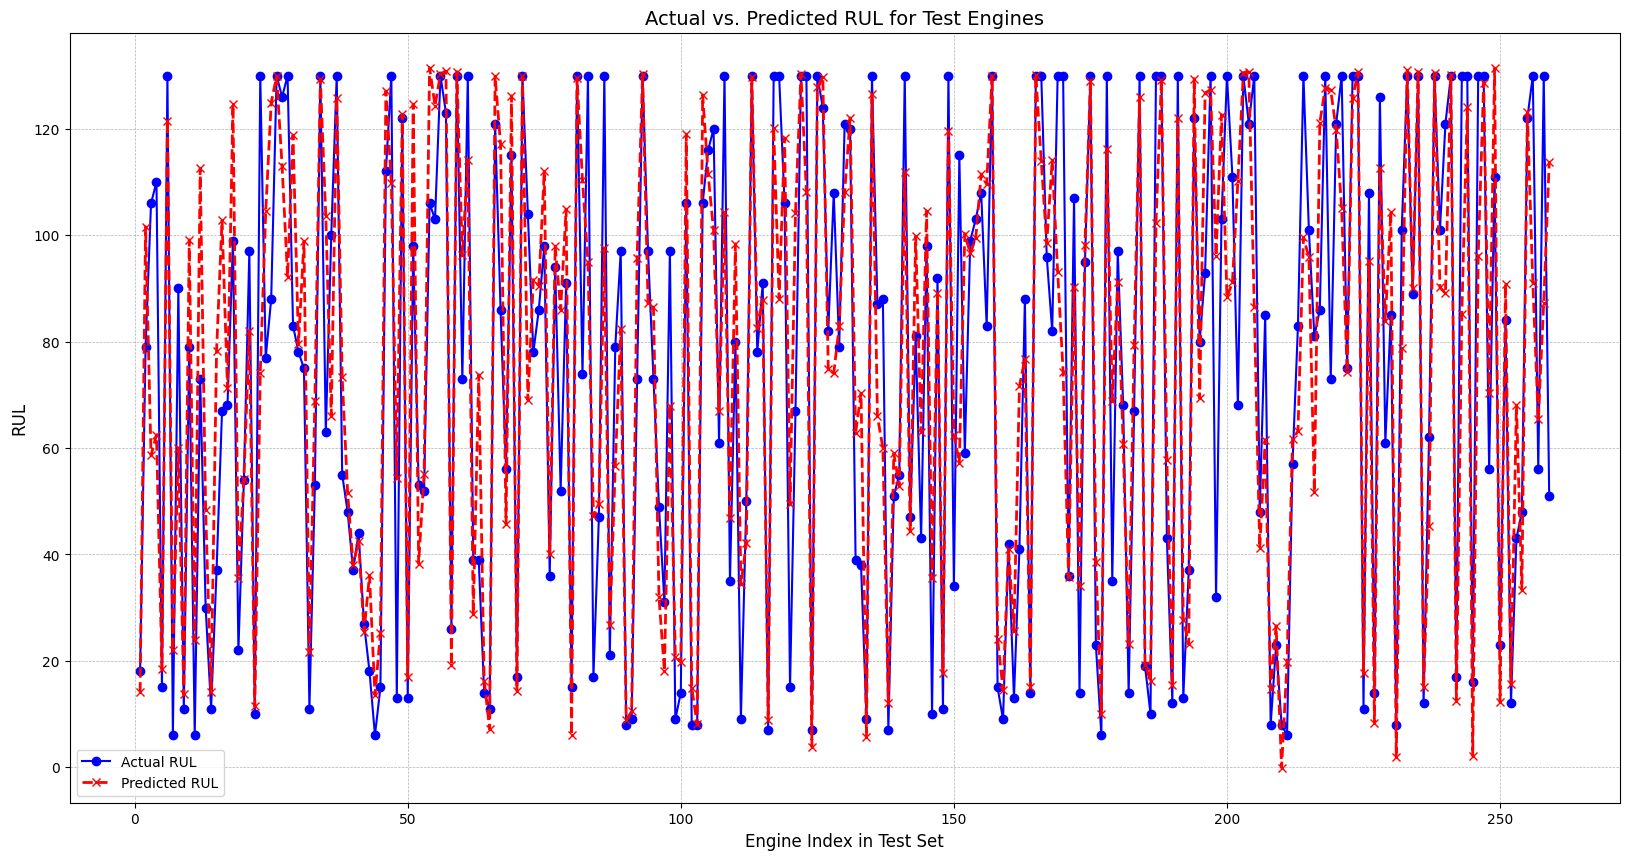

In [68]:
plt.figure(figsize=(20,10))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle=None, linewidth=None, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_NNencoder_gru)+1),y_pred_cycles_kt_NNencoder_gru, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()